<a href="https://colab.research.google.com/github/DungeonProgger/IOS-Android/blob/main/Pract2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Введение и сбор данных

Изначально для извлечения информации о социальных связях планировалось использовать официальный API ВКонтакте. Однако в связи с ужесточением политики платформы, создание полноценного приложения и получение ключей доступа теперь требует верификации статуса юридического лица (ООО или ИП).

В качестве альтернативного решения для сбора информации применялся специализированный сервис парсинга vk.barkov.net. Данный инструмент позволил собрать списки друзей для заданных профилей и сформировать структуру связей (ребер графа) в автоматическом режиме.

Полученные данные были экспортированы в формат CSV. Ниже представлена загрузка этого датасета и вывод фрагмента таблицы, где каждая строка представляет собой направленную связь от одного пользователя к другому.

In [2]:
import pandas as pd

# Загрузка выгруженного датасета
file_name = '/content/drive/MyDrive/Colab Notebooks/Pract/Data.csv'
df = pd.read_csv(file_name, sep=';')

print(f"Таблица успешно загружена. Всего записей (связей): {df.shape[0]}")

display(df.head())

Таблица успешно загружена. Всего записей (связей): 6687


,Найденный друг (ID),Найденный друг (ссылка),Чей это друг (ID),Чей это друг (ссылка)
0,1000921,https://vk.ru/id1000921,214576903,https://vk.ru/id214576903
1,3992468,https://vk.ru/id3992468,214576903,https://vk.ru/id214576903
2,5827148,https://vk.ru/id5827148,214576903,https://vk.ru/id214576903
3,6106776,https://vk.ru/id6106776,214576903,https://vk.ru/id214576903
4,10166431,https://vk.ru/id10166431,214576903,https://vk.ru/id214576903


### 2. Построение социального графа и расчет метрик

В следующем блоке кода выполняется основная обработка собранных данных. Алгоритм решает четыре задачи:

1. **Инициализация сети:** На основе загруженной таблицы с помощью библиотеки `networkx` строится граф, где узлами выступают пользователи, а ребрами — связи между ними.
2. **Идентификация узлов:** Скрипт принимает ссылки на страницы целевых участников (студентов группы) и автоматически сопоставляет их с внутренними ID в выгруженном датасете.
3. **Анализ центральности:** Для всего графа в целом рассчитываются три математические метрики: посредничество (betweenness), близость (closeness) и собственный вектор (eigenvector). Результаты точечно выводятся для выбранных участников.
4. **Визуализация:** С помощью алгоритма `spring_layout` (библиотека `matplotlib`) генерируется визуальное представление структуры связей. Общая масса профилей формирует фон, а исследуемые участники выделяются цветными маркерами для наглядного отображения их положения в сети.

Граф построен: 6562 узлов, 6681 ребер
Рассчитываем метрики (подождите)...

=== Результаты для участников группы БСМО-11-26 ===
Студент https://vk.com/id172152768 (ID 172152768):
  Посредничество: 0.017464 — отражает частоту нахождения узла на кратчайших путях между другими участниками (функция связующего звена).
  Близость:       0.302964 — определяет среднюю дистанцию до всех остальных узлов графа (характеризует потенциальную скорость распространения информации).
  Собств. вектор: 0.000270 — оценивает влиятельность узла с учетом значимости его контактов (связи с центральными узлами дают больший вес, чем с периферийными).
----------------------------------------------------------------------
Студент https://vk.com/id301455650 (ID 301455650):
  Посредничество: 0.016590 — отражает частоту нахождения узла на кратчайших путях между другими участниками (функция связующего звена).
  Близость:       0.302689 — определяет среднюю дистанцию до всех остальных узлов графа (характеризует потенциал

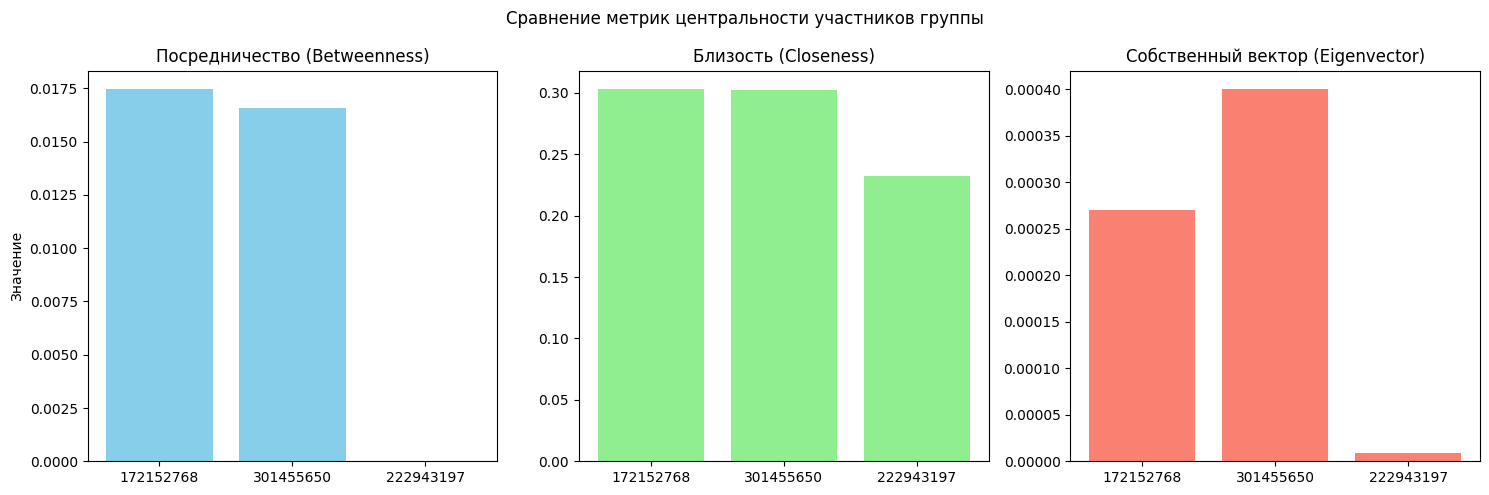

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

file_name = '/content/drive/MyDrive/Colab Notebooks/Pract/Data.csv'
df = pd.read_csv(file_name, sep=';')

G = nx.from_pandas_edgelist(df, source='Чей это друг (ID)', target='Найденный друг (ID)')

print(f"Граф построен: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

group_urls = [
    "https://vk.com/id172152768",
    "https://vk.com/id301455650",
    "https://vk.ru/id222943197"
]

group_ids = []
for url in group_urls:
    short_name = url.split('/')[-1]
    match = df[df['Чей это друг (ссылка)'].str.contains(short_name, na=False)]['Чей это друг (ID)']

    if not match.empty:
        group_ids.append(match.iloc[0])
    else:
        match2 = df[df['Найденный друг (ссылка)'].str.contains(short_name, na=False)]['Найденный друг (ID)']
        if not match2.empty:
            group_ids.append(match2.iloc[0])

print("Рассчитываем метрики (подождите)...")
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)

try:
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = {node: 0 for node in G.nodes()}

labels, b_vals, c_vals, e_vals = [], [], [], []

# 5. Вывод результатов для найденных членов группы
print("\n=== Результаты для участников группы БСМО-11-26 ===")
for i, uid in enumerate(group_ids):
    if uid in G.nodes():
        b = betweenness.get(uid, 0)
        c = closeness.get(uid, 0)
        e = eigenvector.get(uid, 0)

        labels.append(str(uid))
        b_vals.append(b)
        c_vals.append(c)
        e_vals.append(e)

        print(f"Студент {group_urls[i]} (ID {uid}):")
        print(
            f"  Посредничество: {b:.6f} — отражает частоту нахождения узла на кратчайших путях между другими участниками (функция связующего звена).")
        print(
            f"  Близость:       {c:.6f} — определяет среднюю дистанцию до всех остальных узлов графа (характеризует потенциальную скорость распространения информации).")
        print(
            f"  Собств. вектор: {e:.6f} — оценивает влиятельность узла с учетом значимости его контактов (связи с центральными узлами дают больший вес, чем с периферийными).")
        print("-" * 70)

# Построение графиков
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Сравнение метрик центральности участников группы')

ax1.bar(labels, b_vals, color='skyblue')
ax1.set_title('Посредничество (Betweenness)')
ax1.set_ylabel('Значение')

ax2.bar(labels, c_vals, color='lightgreen')
ax2.set_title('Близость (Closeness)')

ax3.bar(labels, e_vals, color='salmon')
ax3.set_title('Собственный вектор (Eigenvector)')

plt.tight_layout()
plt.show()

Визуализация Графа

Рассчитываем координаты графа (это может занять 1-2 минуты)...


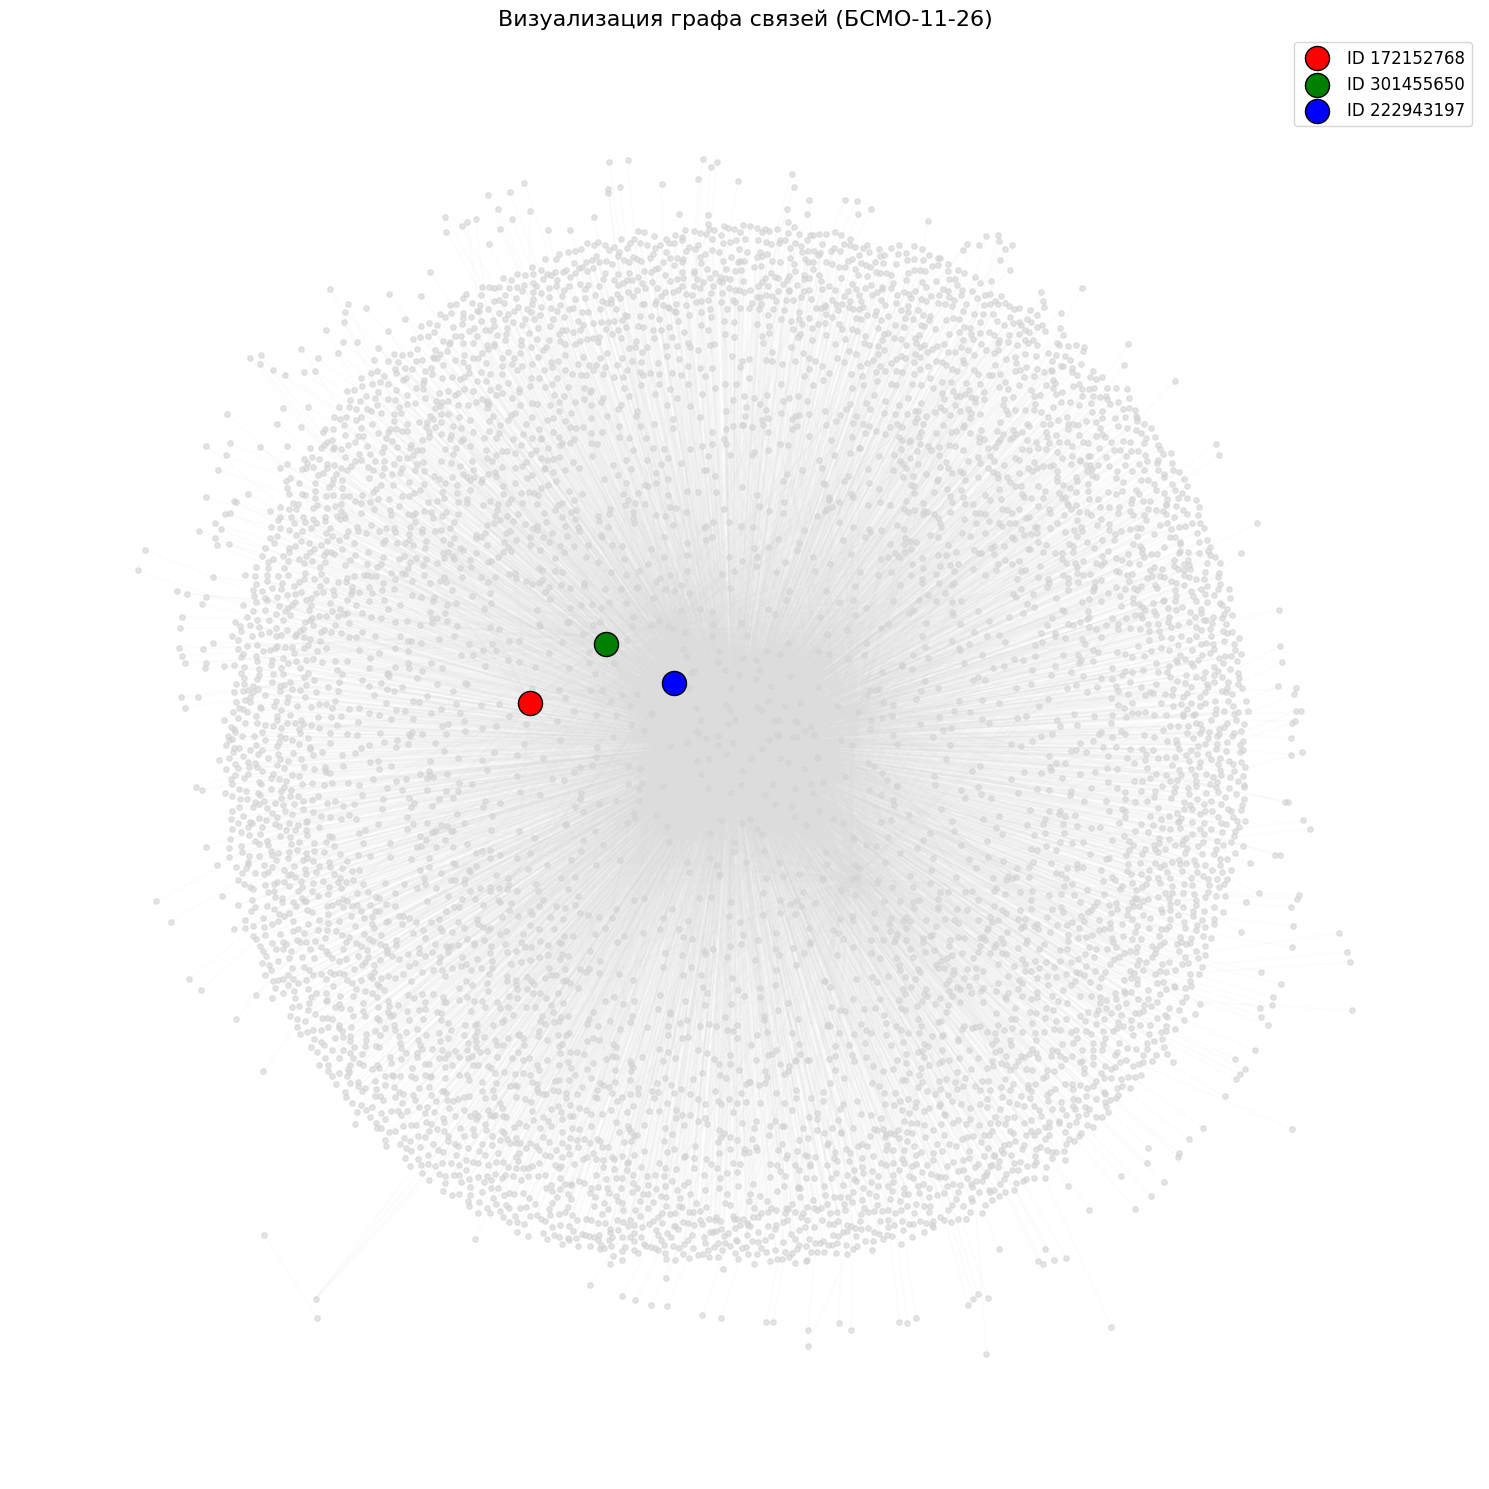

In [3]:
import matplotlib.pyplot as plt

print("Рассчитываем координаты графа (это может занять 1-2 минуты)...")
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(15, 15))
plt.title("Визуализация графа связей (БСМО-11-26)", fontsize=16)

nx.draw_networkx_nodes(G, pos, node_size=15, node_color='lightgray', alpha=0.6)
nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gainsboro')

colors = ['red', 'green', 'blue']

for i, uid in enumerate(group_ids):
    if uid in G.nodes():
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[uid],
            node_size=300,
            node_color=colors[i % len(colors)],
            edgecolors='black',
            label=f"ID {uid}"
        )

plt.axis('off')
plt.legend(scatterpoints=1, loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

### Выводы по результатам анализа социального графа

**Общая топология сети**
В ходе выполнения работы был построен граф социальных связей, включающий 6562 узла и 6681 ребро. Такое соотношение указывает на древовидную или звездообразную структуру сети. Граф выстроен вокруг нескольких центральных профилей, а количество перекрестных связей между остальными участниками минимально.

**Распределение ролей среди участников**

* **Студент ID 172152768:**
Лидирует по метрике посредничества (0.017464) и близости (0.302964). В рамках собранного графа этот человек чаще всего выступает связующим мостом между разрозненными компаниями. Благодаря высокой близости, любая информация от него разойдется по сети за наименьшее число шагов.

* **Студент ID 301455650:**
Обладает самым высоким показателем собственного вектора (0.000400), при этом незначительно уступая первому студенту по остальным параметрам. Это означает, что его личные контакты — наиболее популярные и «весомые» узлы во всей выборке. Он вращается в самом центре наиболее активного ядра сети.

* **Студент ID 222943197:**
Показатель посредничества равен абсолютному нулю (0.000000), а метрики близости (0.232076) и собственного вектора (0.000009) минимальны на фоне остальных. В контексте данной базы данных этот человек находится на самом краю графа — через него не проходят маршруты общения других участников, и его контакты наименее интегрированы в общую массу.

**Заключение**
Расчет метрик центральности успешно дифференцировал участников группы. В сети четко выделяются профили, отвечающие за транзит информации, скрытые лидеры с наиболее качественными и статусными связями, а также периферийные узлы с локализованным кругом общения.